In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

In [ ]:
df = pd.read_csv('access_control_authentic_500k.csv', low_memory=False)

In [ ]:
df.shape

(500000, 22)

In [ ]:
df.size

11000000

In [ ]:
df.columns

Index(['user_id', 'username', 'role', 'department', 'login_time',
       'access_request_type', 'resource_requested', 'access_granted',
       'ip_address', 'device_type', 'location', 'time_of_day', 'day_of_week',
       'previous_access_count', 'failed_login_attempts', 'account_age_days',
       'last_password_change_days', 'access_sensitivity_level', 'risk_score',
       'anomaly_detected', 'user_behavior_score', 'compliance_status'],
      dtype='str')

In [ ]:
df.describe()

,access_granted,previous_access_count,failed_login_attempts,account_age_days,last_password_change_days,risk_score,anomaly_detected,user_behavior_score
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,0.558782,6023.416478,0.068312,634.071898,89.997158,0.535992,0.171720,0.839994
std,0.496533,3153.383297,0.390929,259.695676,51.597125,0.185421,0.377137,0.131738
min,0.000000,900.000000,0.000000,180.000000,1.000000,0.080600,0.000000,0.300000
25%,0.000000,3525.000000,0.000000,414.000000,45.000000,0.410800,0.000000,0.791400
50%,1.000000,5432.000000,0.000000,623.000000,90.000000,0.531900,0.000000,0.861100
75%,1.000000,8060.000000,0.000000,853.000000,135.000000,0.664500,0.000000,0.930400
max,1.000000,15316.000000,4.000000,1094.000000,179.000000,1.000000,1.000000,1.000000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   user_id                    500000 non-null  str    
 1   username                   500000 non-null  str    
 2   role                       500000 non-null  str    
 3   department                 500000 non-null  str    
 4   login_time                 500000 non-null  str    
 5   access_request_type        500000 non-null  str    
 6   resource_requested         500000 non-null  str    
 7   access_granted             500000 non-null  int64  
 8   ip_address                 500000 non-null  str    
 9   device_type                500000 non-null  str    
 10  location                   500000 non-null  str    
 11  time_of_day                500000 non-null  str    
 12  day_of_week                500000 non-null  str    
 13  previous_access_count      500000 non-nu

In [ ]:
df.isnull().sum()

user_id                      0
username                     0
role                         0
department                   0
login_time                   0
access_request_type          0
resource_requested           0
access_granted               0
ip_address                   0
device_type                  0
location                     0
time_of_day                  0
day_of_week                  0
previous_access_count        0
failed_login_attempts        0
account_age_days             0
last_password_change_days    0
access_sensitivity_level     0
risk_score                   0
anomaly_detected             0
user_behavior_score          0
compliance_status            0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['login_time'] = pd.to_datetime(df['login_time'], errors='coerce')

cat_cols = [
    'user_id', 'username', 'role', 'department', 'access_request_type',
    'resource_requested', 'ip_address', 'device_type', 'location',
    'time_of_day', 'day_of_week', 'access_sensitivity_level',
    'compliance_status'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   user_id                    500000 non-null  category      
 1   username                   500000 non-null  category      
 2   role                       500000 non-null  category      
 3   department                 500000 non-null  category      
 4   login_time                 500000 non-null  datetime64[us]
 5   access_request_type        500000 non-null  category      
 6   resource_requested         500000 non-null  category      
 7   access_granted             500000 non-null  int64         
 8   ip_address                 500000 non-null  category      
 9   device_type                500000 non-null  category      
 10  location                   500000 non-null  category      
 11  time_of_day                500000 non-null  category      
 12 

In [ ]:
print(df['access_granted'].value_counts())
print(df['anomaly_detected'].value_counts())

access_granted
1    279391
0    220609
Name: count, dtype: int64
anomaly_detected
0    414140
1     85860
Name: count, dtype: int64


In [ ]:
print(df[['risk_score', 'user_behavior_score']].describe())

          risk_score  user_behavior_score
count  500000.000000        500000.000000
mean        0.535992             0.839994
std         0.185421             0.131738
min         0.080600             0.300000
25%         0.410800             0.791400
50%         0.531900             0.861100
75%         0.664500             0.930400
max         1.000000             1.000000


In [ ]:
for col in ['role', 'department', 'access_request_type', 'device_type',
            'location', 'time_of_day', 'day_of_week',
            'access_sensitivity_level', 'compliance_status']:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


role
role
CEO               45332
Senior Dev        40514
Admin             40421
Coordinator       39935
Junior Dev        39495
Developer         39113
Data Scientist    39061
Analyst           38005
VP                36978
Manager           36795
Name: count, dtype: int64

department
department
HR             38854
Admin          36191
Legal          34331
Engineering    34174
IT             34068
Marketing      34022
Product        33402
Operations     33398
Risk           33232
Security       33109
Name: count, dtype: int64

access_request_type
access_request_type
Application Access    125456
Database Access       125098
File Access           124665
API Access             74777
VPN Access             50004
Name: count, dtype: int64

device_type
device_type
Desktop       200154
Laptop        174890
Mobile         74979
VPN_Client     49977
Name: count, dtype: int64

location
location
Office    325156
Home       99416
Remote     50386
Branch     25042
Name: count, dtype: int64

tim

In [ ]:
print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())

print("\nAccess Granted Distribution:")
print(df['access_granted'].value_counts(normalize=True) * 100)

print("\nAnomaly Distribution:")
print(df['anomaly_detected'].value_counts(normalize=True) * 100)

print("\nCompliance Distribution:")
print(df['compliance_status'].value_counts(normalize=True) * 100)

Shape: (500000, 22)
Duplicates: 0

Access Granted Distribution:
access_granted
1    55.8782
0    44.1218
Name: proportion, dtype: float64

Anomaly Distribution:
anomaly_detected
0    82.828
1    17.172
Name: proportion, dtype: float64

Compliance Distribution:
compliance_status
Non-Compliant    69.4416
Compliant        30.5584
Name: proportion, dtype: float64


In [ ]:
# Access granted by role
print(df.groupby('role')['access_granted'].mean().sort_values(ascending=False))

# Access granted by department
print(df.groupby('department')['access_granted'].mean().sort_values(ascending=False))

# Anomaly rate by time of day
print(df.groupby('time_of_day')['anomaly_detected'].mean().sort_values(ascending=False))

# Risk score by compliance status
print(df.groupby('compliance_status')['risk_score'].mean().sort_values(ascending=False))

# User behavior score by anomaly flag
print(df.groupby('anomaly_detected')['user_behavior_score'].mean())

role
Specialist        0.563512
VP                0.563227
Admin             0.561193
Manager           0.559424
Developer         0.559354
Director          0.559323
Support           0.559110
Analyst           0.557927
CEO               0.556935
Senior Dev        0.556820
Coordinator       0.556655
Data Scientist    0.556642
Junior Dev        0.555235
Name: access_granted, dtype: float64
department
Operations     0.566381
Legal          0.561708
HR             0.560586
Marketing      0.560520
Sales          0.560219
Product        0.559787
Data           0.559036
Security       0.557915
Support        0.557839
Engineering    0.557705
Admin          0.556962
Risk           0.556572
IT             0.556329
Compliance     0.555372
Finance        0.554154
Name: access_granted, dtype: float64
time_of_day
Night        0.246581
Evening      0.069458
Morning      0.068694
Afternoon    0.067563
Name: anomaly_detected, dtype: float64
compliance_status
Non-Compliant    0.615965
Compliant       

In [ ]:
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
# 3. Numeric summary
print("\nNumeric summary:")
display(df[['previous_access_count', 'failed_login_attempts', 'account_age_days',
            'last_password_change_days', 'risk_score', 'user_behavior_score']].describe())


Numeric summary:


,previous_access_count,failed_login_attempts,account_age_days,last_password_change_days,risk_score,user_behavior_score
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,6023.416478,0.068312,634.071898,89.997158,0.535992,0.839994
std,3153.383297,0.390929,259.695676,51.597125,0.185421,0.131738
min,900.000000,0.000000,180.000000,1.000000,0.080600,0.300000
25%,3525.000000,0.000000,414.000000,45.000000,0.410800,0.791400
50%,5432.000000,0.000000,623.000000,90.000000,0.531900,0.861100
75%,8060.000000,0.000000,853.000000,135.000000,0.664500,0.930400
max,15316.000000,4.000000,1094.000000,179.000000,1.000000,1.000000


In [ ]:
# 4. Access granted by role
role_access = df.groupby('role')['access_granted'].mean().sort_values(ascending=False)

/tmp/ipykernel_14199/217296163.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=role_access.index, y=role_access.values, palette="viridis")


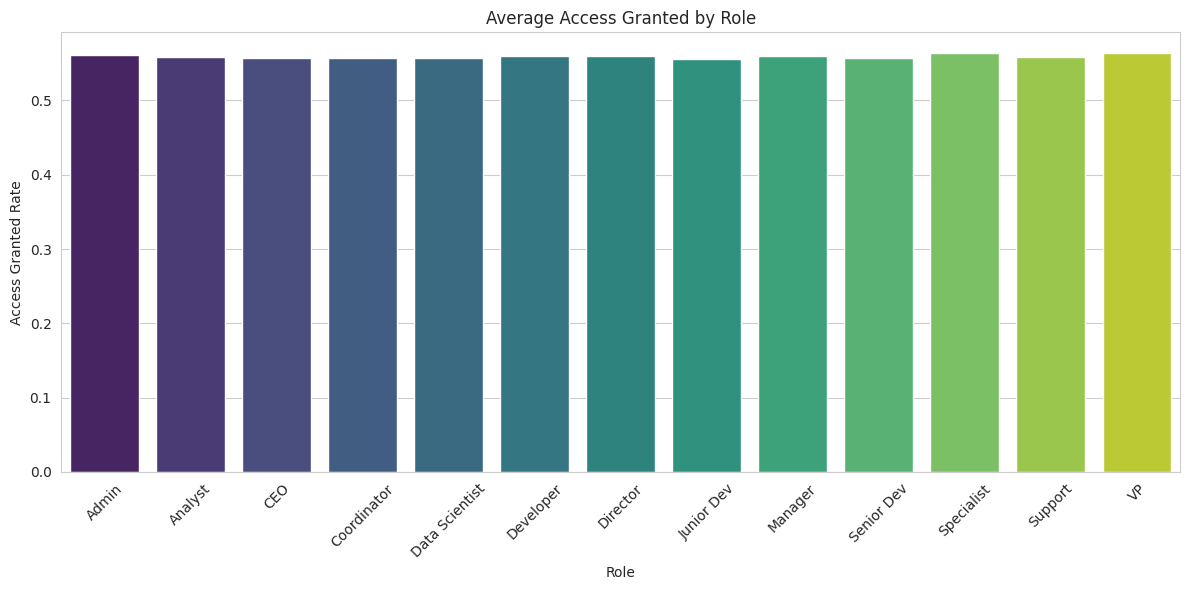

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=role_access.index, y=role_access.values, palette="viridis")
plt.title("Average Access Granted by Role")
plt.ylabel("Access Granted Rate")
plt.xlabel("Role")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
 #5. Access granted by department
dept_access = df.groupby('department')['access_granted'].mean().sort_values(ascending=False)

C:\Users\eshan\AppData\Local\Temp\ipykernel_14812\283519780.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_access.index, y=dept_access.values, palette="crest")


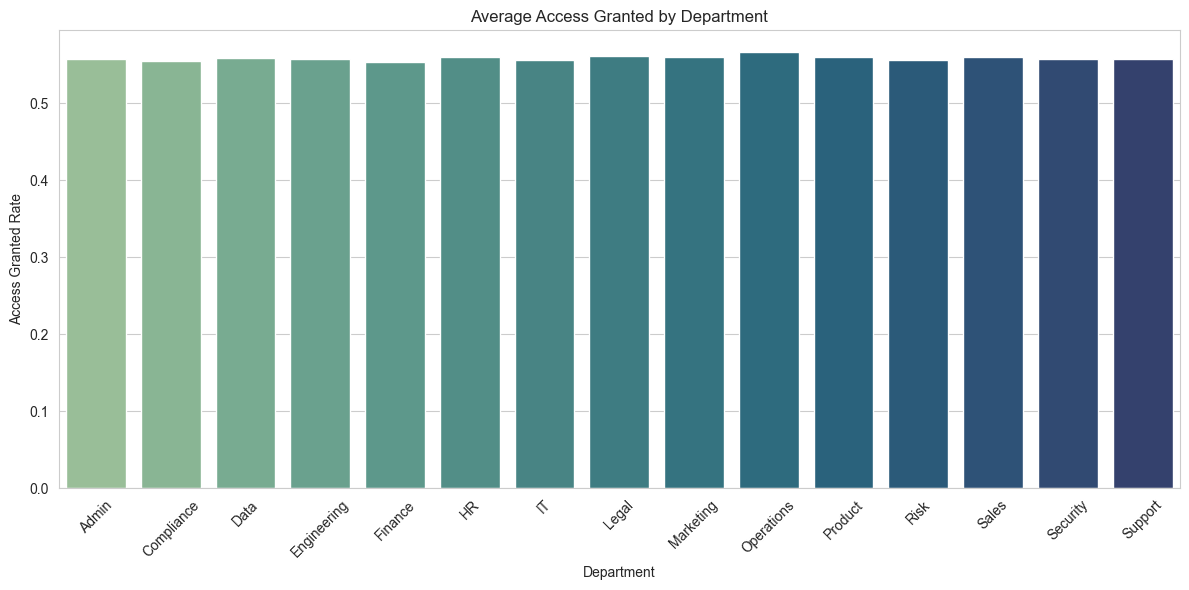

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=dept_access.index, y=dept_access.values, palette="crest")
plt.title("Average Access Granted by Department")
plt.ylabel("Access Granted Rate")
plt.xlabel("Department")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 6. Anomaly rate by time of day
time_anomaly = df.groupby('time_of_day')['anomaly_detected'].mean().sort_values(ascending=False)

C:\Users\eshan\AppData\Local\Temp\ipykernel_14812\557157753.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=time_anomaly.index, y=time_anomaly.values, palette="rocket")


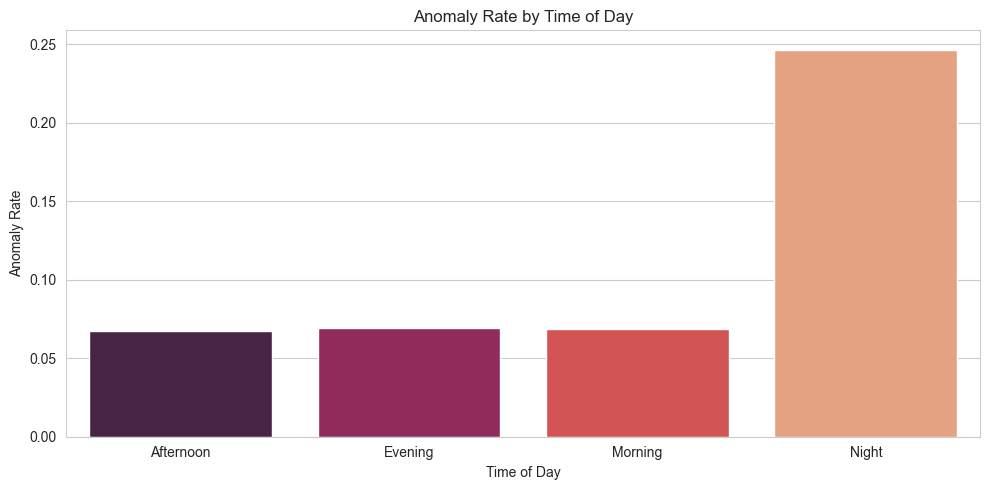

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=time_anomaly.index, y=time_anomaly.values, palette="rocket")
plt.title("Anomaly Rate by Time of Day")
plt.ylabel("Anomaly Rate")
plt.xlabel("Time of Day")
plt.tight_layout()
plt.show()

C:\Users\eshan\AppData\Local\Temp\ipykernel_14812\2151182052.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='compliance_status', y='risk_score', palette="Set2")


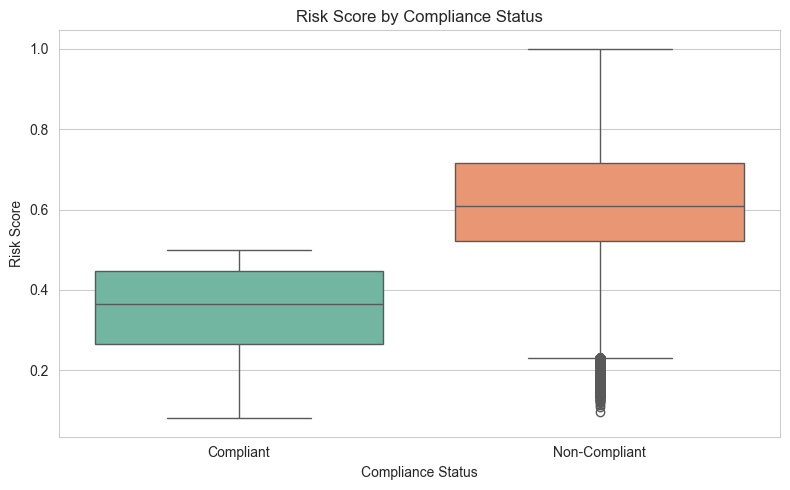

In [ ]:
# 7. Risk score by compliance status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='compliance_status', y='risk_score', palette="Set2")
plt.title("Risk Score by Compliance Status")
plt.xlabel("Compliance Status")
plt.ylabel("Risk Score")
plt.tight_layout()
plt.show()

C:\Users\eshan\AppData\Local\Temp\ipykernel_14812\4258356673.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='anomaly_detected', y='user_behavior_score', palette="Set1")


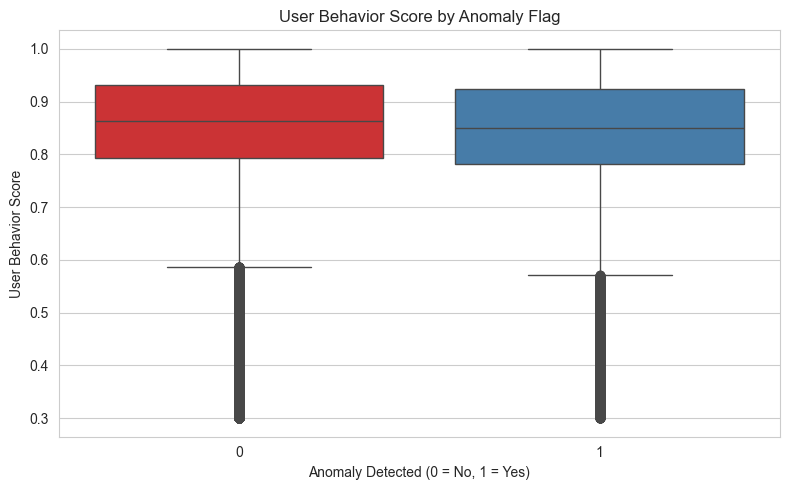

In [ ]:
# 8. User behavior score by anomaly flag
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='anomaly_detected', y='user_behavior_score', palette="Set1")
plt.title("User Behavior Score by Anomaly Flag")
plt.xlabel("Anomaly Detected (0 = No, 1 = Yes)")
plt.ylabel("User Behavior Score")
plt.tight_layout()
plt.show()

In [ ]:
# 9. Failed logins by sensitivity level
sens_fail = df.groupby('access_sensitivity_level')['failed_login_attempts'].mean().sort_values(ascending=False)

C:\Users\eshan\AppData\Local\Temp\ipykernel_14812\3547547527.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sens_fail.index, y=sens_fail.values, palette="magma")


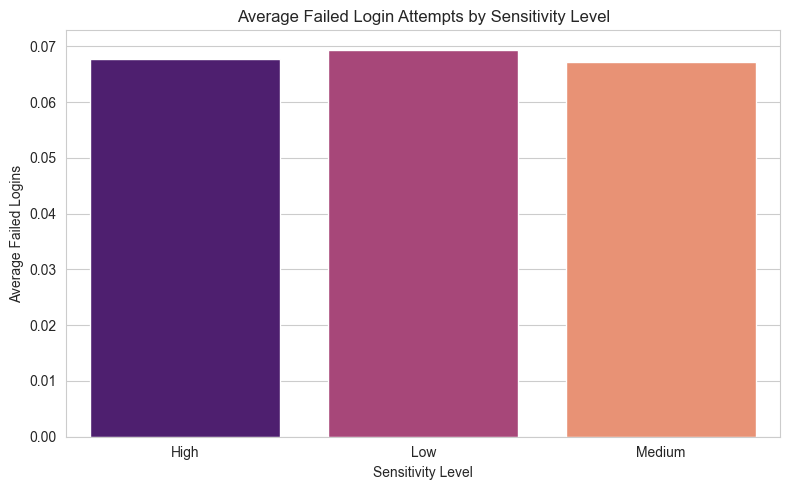

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=sens_fail.index, y=sens_fail.values, palette="magma")
plt.title("Average Failed Login Attempts by Sensitivity Level")
plt.xlabel("Sensitivity Level")
plt.ylabel("Average Failed Logins")
plt.tight_layout()
plt.show()

In [ ]:
# 10. Access granted by device type
device_access = df.groupby('device_type')['access_granted'].mean().sort_values(ascending=False)

C:\Users\eshan\AppData\Local\Temp\ipykernel_14812\2182064039.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_access.index, y=device_access.values, palette="cubehelix")


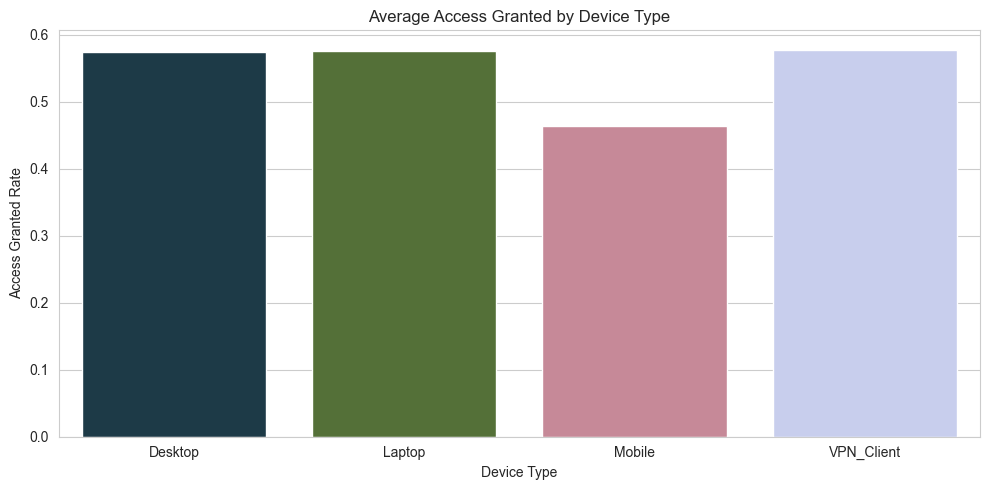

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=device_access.index, y=device_access.values, palette="cubehelix")
plt.title("Average Access Granted by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Access Granted Rate")
plt.tight_layout()
plt.show()

In [ ]:
# 11. Correlation heatmap for numeric columns
num_cols = ['access_granted', 'previous_access_count', 'failed_login_attempts',
            'account_age_days', 'last_password_change_days',
            'risk_score', 'anomaly_detected', 'user_behavior_score']

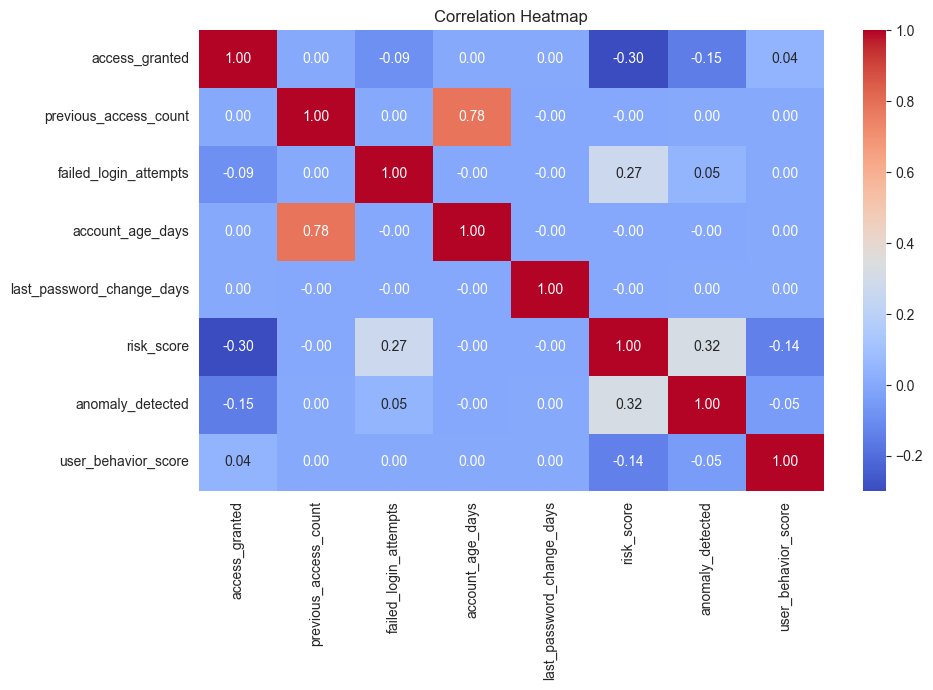

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# Copy first so original df stays unchanged
df_fe = df.copy()

In [ ]:
# Datetime features
df_fe['login_hour'] = df_fe['login_time'].dt.hour
df_fe['login_month'] = df_fe['login_time'].dt.month
df_fe['login_day'] = df_fe['login_time'].dt.day
df_fe['login_is_weekend'] = df_fe['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

In [ ]:
# Time-based risk flags
df_fe['off_hours_access'] = df_fe['time_of_day'].isin(['Night', 'Evening']).astype(int)
df_fe['high_risk_request'] = df_fe['access_sensitivity_level'].eq('High').astype(int)
df_fe['medium_or_high_sensitivity'] = df_fe['access_sensitivity_level'].isin(['Medium', 'High']).astype(int)

In [ ]:
# Behavior flags
df_fe['many_previous_accesses'] = (df_fe['previous_access_count'] > df_fe['previous_access_count'].median()).astype(int)
df_fe['high_failed_logins'] = (df_fe['failed_login_attempts'] >= 3).astype(int)
df_fe['old_password_change'] = (df_fe['last_password_change_days'] > 90).astype(int)
df_fe['young_account'] = (df_fe['account_age_days'] < 30).astype(int)

In [ ]:
# Risk-based flags
df_fe['high_risk_score'] = (df_fe['risk_score'] >= df_fe['risk_score'].median()).astype(int)
df_fe['high_behavior_risk'] = (df_fe['user_behavior_score'] < df_fe['user_behavior_score'].median()).astype(int)

In [ ]:
# Compliance flags
df_fe['non_compliant_flag'] = df_fe['compliance_status'].eq('Non-Compliant').astype(int)

In [ ]:
# Combined features
df_fe['suspicious_access'] = (
    df_fe['off_hours_access'] +
    df_fe['high_failed_logins'] +
    df_fe['high_risk_request'] +
    df_fe['non_compliant_flag']
)

In [ ]:
df_fe['security_risk_band'] = pd.cut(
    df_fe['risk_score'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)


In [ ]:
# Quick checks
print(df_fe.shape)
df_fe.head()

(500000, 38)


,user_id,username,role,department,login_time,access_request_type,resource_requested,access_granted,ip_address,device_type,location,time_of_day,day_of_week,previous_access_count,failed_login_attempts,account_age_days,last_password_change_days,access_sensitivity_level,risk_score,anomaly_detected,user_behavior_score,compliance_status,login_hour,login_month,login_day,login_is_weekend,off_hours_access,high_risk_request,medium_or_high_sensitivity,many_previous_accesses,high_failed_logins,old_password_change,young_account,high_risk_score,high_behavior_risk,non_compliant_flag,suspicious_access,security_risk_band
0,U01310,u01310.user,Manager,Marketing,2024-10-01 01:37:54,Database Access,employee_records,1,192.168.1.135,Desktop,Office,Night,Tuesday,2412,0,402,124,Medium,0.6101,0,0.4850,Non-Compliant,1,10,1,0,1,0,1,0,0,1,0,1,1,1,2,Medium
1,U00229,u00229.user,Junior Dev,Support,2024-10-01 08:03:06,Database Access,email_system,1,203.251.250.247,Laptop,Home,Morning,Tuesday,2570,1,257,162,Low,0.5943,1,0.7576,Non-Compliant,8,10,1,0,0,0,0,0,0,1,0,1,1,1,1,Medium
2,U00052,u00052.user,VP,Security,2024-10-01 00:11:28,File Access,master_data,1,192.168.2.4,Desktop,Office,Night,Tuesday,5660,0,566,137,Low,0.5178,0,0.8417,Non-Compliant,0,10,1,0,1,0,0,1,0,1,0,0,1,1,2,Medium
3,U01519,u01519.user,Senior Dev,Legal,2024-10-01 00:02:03,Database Access,reference_data,0,192.168.35.223,Desktop,Office,Night,Tuesday,8680,0,1085,141,Medium,0.5337,0,0.9218,Non-Compliant,0,10,1,0,1,0,1,1,0,1,0,1,0,1,2,Medium
4,U00564,u00564.user,Coordinator,Compliance,2024-10-01 04:51:27,API Access,budgeting_system,0,203.110.106.183,Laptop,Home,Night,Tuesday,5304,0,442,103,Low,0.7647,0,0.4013,Non-Compliant,4,10,1,0,1,0,0,0,0,1,0,1,1,1,2,High


In [ ]:
# 1. Quick checks
print("Shape:", df_fe.shape)
print("Duplicates:", df_fe.duplicated().sum())

Shape: (500000, 38)
Duplicates: 0


In [ ]:
# 2. Suspicious access vs anomaly
print("\nSuspicious access vs anomaly:")
print(pd.crosstab(df_fe['suspicious_access'], df_fe['anomaly_detected'], normalize='index'))


Suspicious access vs anomaly:
anomaly_detected          0         1
suspicious_access                    
0                  1.000000  0.000000
1                  0.937274  0.062726
2                  0.740616  0.259384
3                  0.702216  0.297784
4                  0.679012  0.320988


C:\Users\eshan\AppData\Local\Temp\ipykernel_14812\1808975018.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


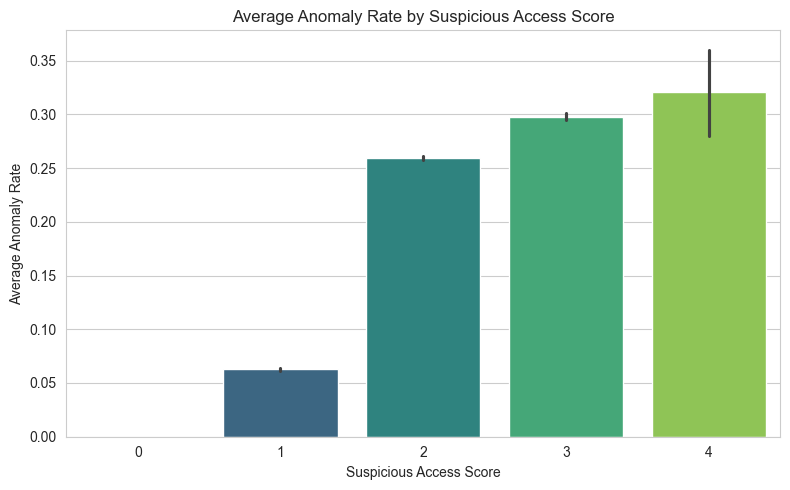

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_fe,
    x='suspicious_access',
    y='anomaly_detected',
    estimator=np.mean,
    palette='viridis'
)
plt.title("Average Anomaly Rate by Suspicious Access Score")
plt.xlabel("Suspicious Access Score")
plt.ylabel("Average Anomaly Rate")
plt.tight_layout()
plt.show()

In [ ]:
# 3. Off-hours access vs granted
print("\nOff-hours access vs access granted:")
print(pd.crosstab(df_fe['off_hours_access'], df_fe['access_granted'], normalize='index'))


Off-hours access vs access granted:
access_granted           0         1
off_hours_access                    
0                 0.323183  0.676817
1                 0.510769  0.489231


C:\Users\eshan\AppData\Local\Temp\ipykernel_14812\757257148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


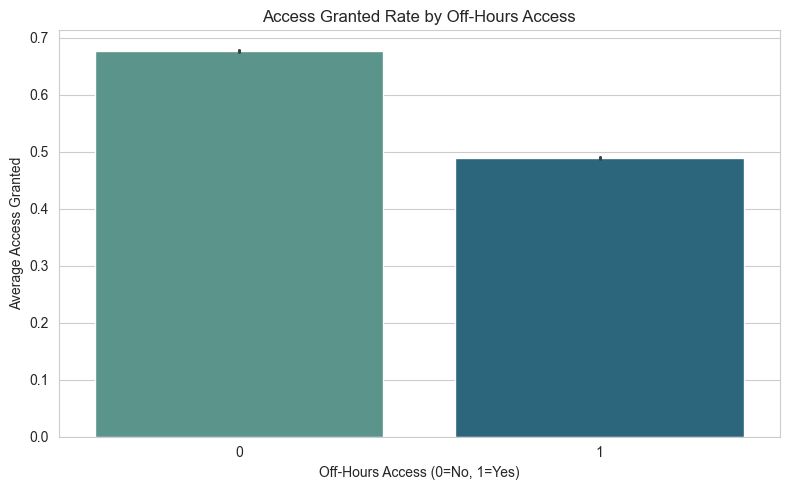

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_fe,
    x='off_hours_access',
    y='access_granted',
    estimator=np.mean,
    palette='crest'
)
plt.title("Access Granted Rate by Off-Hours Access")
plt.xlabel("Off-Hours Access (0=No, 1=Yes)")
plt.ylabel("Average Access Granted")
plt.tight_layout()
plt.show()

In [ ]:
# 4. High failed logins vs access granted
print("\nHigh failed logins vs access granted:")
print(pd.crosstab(df_fe['high_failed_logins'], df_fe['access_granted'], normalize='index'))


High failed logins vs access granted:
access_granted             0         1
high_failed_logins                    
0                   0.437930  0.562070
1                   0.847534  0.152466


C:\Users\eshan\AppData\Local\Temp\ipykernel_14812\187310619.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


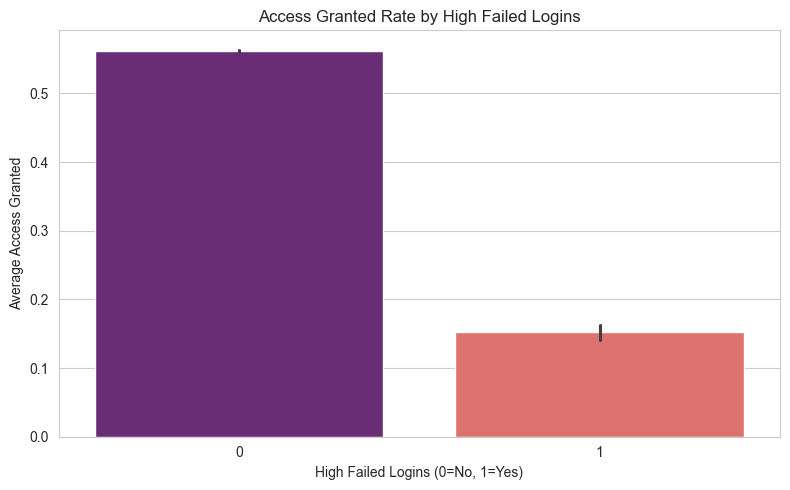

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_fe,
    x='high_failed_logins',
    y='access_granted',
    estimator=np.mean,
    palette='magma'
)
plt.title("Access Granted Rate by High Failed Logins")
plt.xlabel("High Failed Logins (0=No, 1=Yes)")
plt.ylabel("Average Access Granted")
plt.tight_layout()
plt.show()

In [ ]:
# 5. Security risk band vs compliance
print("\nSecurity risk band vs compliance status:")
print(pd.crosstab(df_fe['security_risk_band'], df_fe['compliance_status'], normalize='index'))



Security risk band vs compliance status:
compliance_status   Compliant  Non-Compliant
security_risk_band                          
Low                  0.799269       0.200731
Medium               0.305557       0.694443
High                 0.000000       1.000000


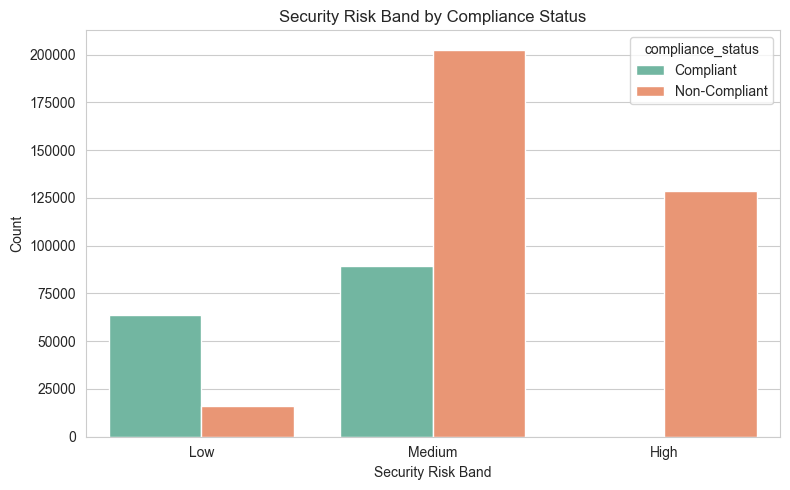

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_fe, x='security_risk_band', hue='compliance_status', palette='Set2')
plt.title("Security Risk Band by Compliance Status")
plt.xlabel("Security Risk Band")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# 6. High risk score vs anomaly
print("\nHigh risk score vs anomaly detected:")
print(pd.crosstab(df_fe['high_risk_score'], df_fe['anomaly_detected'], normalize='index'))


High risk score vs anomaly detected:
anomaly_detected         0         1
high_risk_score                     
0                 0.958435  0.041565
1                 0.698205  0.301795


C:\Users\eshan\AppData\Local\Temp\ipykernel_14812\3552131606.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


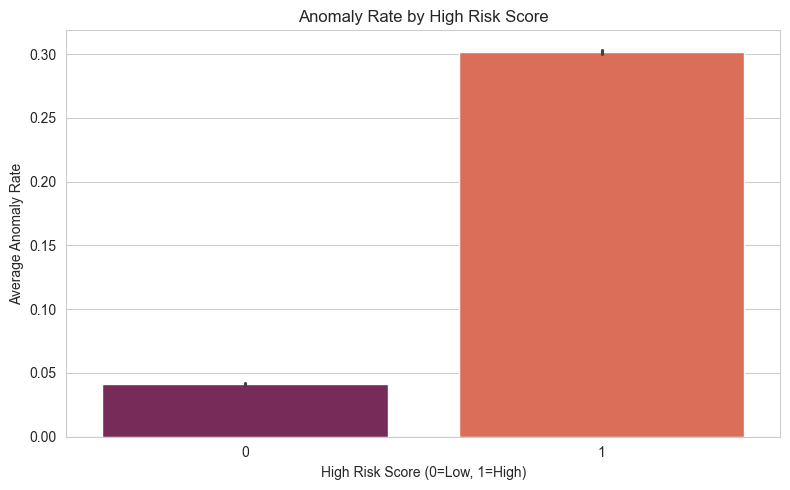

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_fe,
    x='high_risk_score',
    y='anomaly_detected',
    estimator=np.mean,
    palette='rocket'
)
plt.title("Anomaly Rate by High Risk Score")
plt.xlabel("High Risk Score (0=Low, 1=High)")
plt.ylabel("Average Anomaly Rate")
plt.tight_layout()
plt.show()

In [ ]:
# 7. High behavior risk vs anomaly
print("\nHigh behavior risk vs anomaly detected:")
print(pd.crosstab(df_fe['high_behavior_risk'], df_fe['anomaly_detected'], normalize='index'))



High behavior risk vs anomaly detected:
anomaly_detected           0         1
high_behavior_risk                    
0                   0.840949  0.159051
1                   0.815600  0.184400


C:\Users\eshan\AppData\Local\Temp\ipykernel_14812\4178877559.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


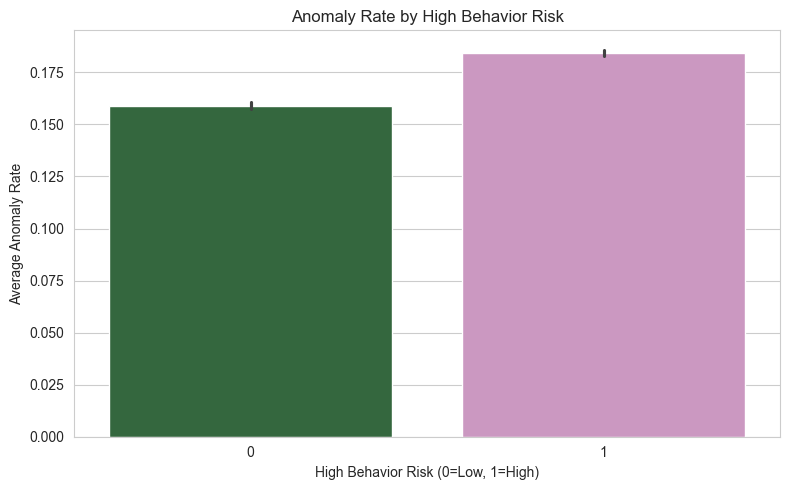

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_fe,
    x='high_behavior_risk',
    y='anomaly_detected',
    estimator=np.mean,
    palette='cubehelix'
)
plt.title("Anomaly Rate by High Behavior Risk")
plt.xlabel("High Behavior Risk (0=Low, 1=High)")
plt.ylabel("Average Anomaly Rate")
plt.tight_layout()
plt.show()

In [ ]:
# 8. Correlation of new numeric features
new_num_cols = [
    'previous_access_count', 'failed_login_attempts', 'account_age_days',
    'last_password_change_days', 'risk_score', 'anomaly_detected',
    'user_behavior_score', 'login_hour', 'login_month', 'login_day',
    'login_is_weekend', 'off_hours_access', 'high_risk_request',
    'medium_or_high_sensitivity', 'many_previous_accesses',
    'high_failed_logins', 'old_password_change', 'young_account',
    'high_risk_score', 'high_behavior_risk', 'non_compliant_flag',
    'suspicious_access'
]

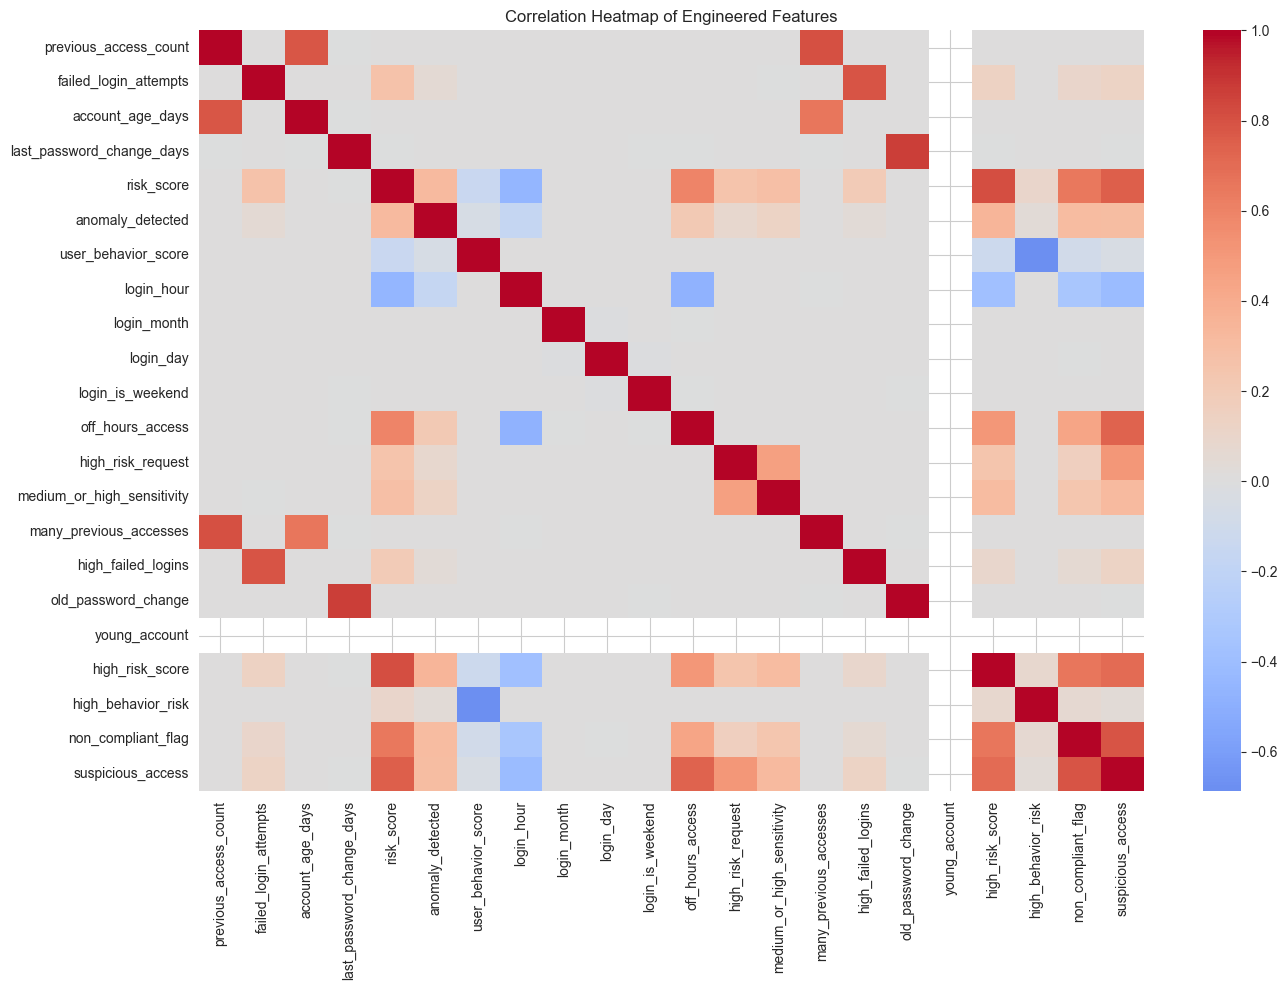

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_fe[new_num_cols].corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Engineered Features")
plt.tight_layout()
plt.show()

In [ ]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 2.3 MB/s eta 0:02:35
   ---------------------------------------- 1.3/351.2 MB 3.0 MB/s eta 0:01:56
   ---------------------------------------- 2.4/351.2 MB 3.9 MB/s eta 0:01:30
   ---------------------------------------- 3.7/351.2 MB 4.3 MB/s eta 0:01:22
    --------------------------------------- 4.7/351.2 MB 4.6 MB/s eta 0:01:17
    --------------------------------------- 6.0/351.2 MB 4.7 MB/s eta 0:01:14
    --------------------------------------- 7.3/351.2 MB 4.9 MB/s eta 0:01:10
   - -------------------------------------- 9.7/351.2 MB 5.5 MB/s eta 0:01:02
   - -------------------------------------- 10.7/351.2 MB 5.5 MB/s eta 0:01:03
   - -------------------------------------- 12.3/351.2 MB 5.7 MB/s eta 0:01:00
   - -------------------------------------- 12.8/351.2 MB 5.3 MB/s eta 0:01:


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
# Copy engineered data
model_df = df_fe.copy()

In [ ]:
# Drop columns not needed for modeling
drop_cols = ['username', 'login_time', 'ip_address']
for col in drop_cols:
    if col in model_df.columns:
        model_df = model_df.drop(columns=col)

In [ ]:
# Target
target = 'access_granted'

In [ ]:
# Separate features and target
X = model_df.drop(columns=[target])
y = model_df[target]

In [ ]:
# One-hot encode categorical columns
cat_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)


In [ ]:
# Align if any missing values after encoding
X = X.fillna(0)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Neural network model
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=2048,
    verbose=1
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.6521 - auc: 0.7194 - loss: 0.5801 - val_accuracy: 0.7479 - val_auc: 0.8102 - val_loss: 0.4488
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.7436 - auc: 0.8225 - loss: 0.4364 - val_accuracy: 0.7483 - val_auc: 0.8381 - val_loss: 0.4182
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.7459 - auc: 0.8418 - loss: 0.4175 - val_accuracy: 0.7480 - val_auc: 0.8430 - val_loss: 0.4147
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.7492 - auc: 0.8494 - loss: 0.4118 - val_accuracy: 0.7477 - val_auc: 0.8455 - val_loss: 0.4128
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.7518 - auc: 0.8539 - loss: 0.4083 - val_accuracy: 0.7467 - val_auc: 0.8458 - val_loss: 0.4119
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.7546 - auc: 0.8571 - loss: 0.4050 - val_accuracy: 0.7435 - val_auc: 0.8464 - val_loss: 0.4115
Epoch 7/10
157/157 ━━━━━━━━━━━━━

In [ ]:
y_prob = model.predict(X_test_scaled).ravel()
y_pred = (y_prob >= 0.5).astype(int)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.74401
ROC AUC: 0.8495353371551799

Confusion Matrix:
[[33850 10272]
 [15327 40551]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.77      0.73     44122
           1       0.80      0.73      0.76     55878

    accuracy                           0.74    100000
   macro avg       0.74      0.75      0.74    100000
weighted avg       0.75      0.74      0.74    100000



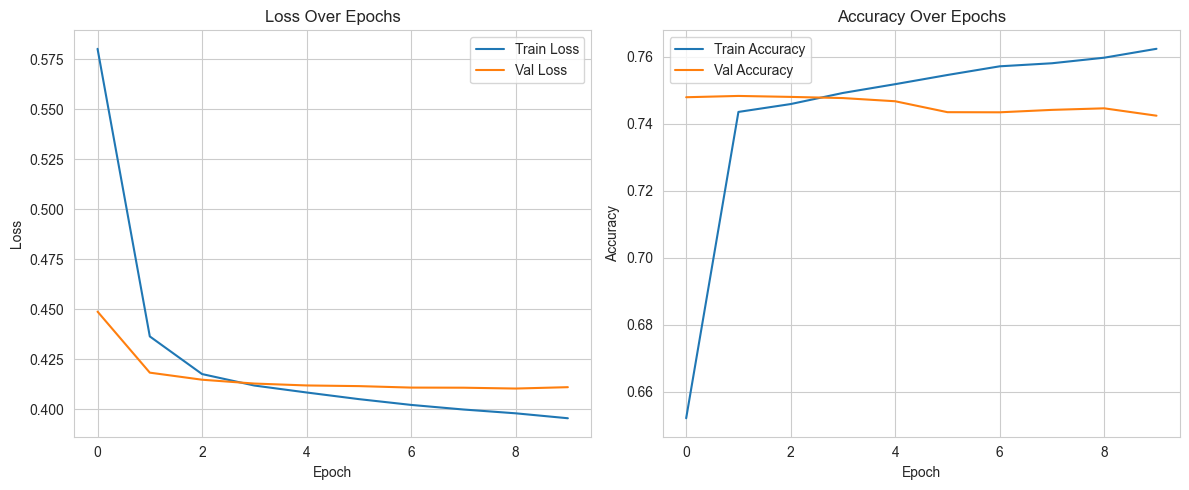

In [ ]:
# Training history plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score, classification_report, confusion_matrix
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

y_pred_best = (y_prob >= best_threshold).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Best threshold: 0.41844073
Best F1: 0.7742414495579082

Confusion Matrix:
[[19931 24191]
 [ 5303 50575]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.45      0.57     44122
           1       0.68      0.91      0.77     55878

    accuracy                           0.71    100000
   macro avg       0.73      0.68      0.67    100000
weighted avg       0.73      0.71      0.69    100000



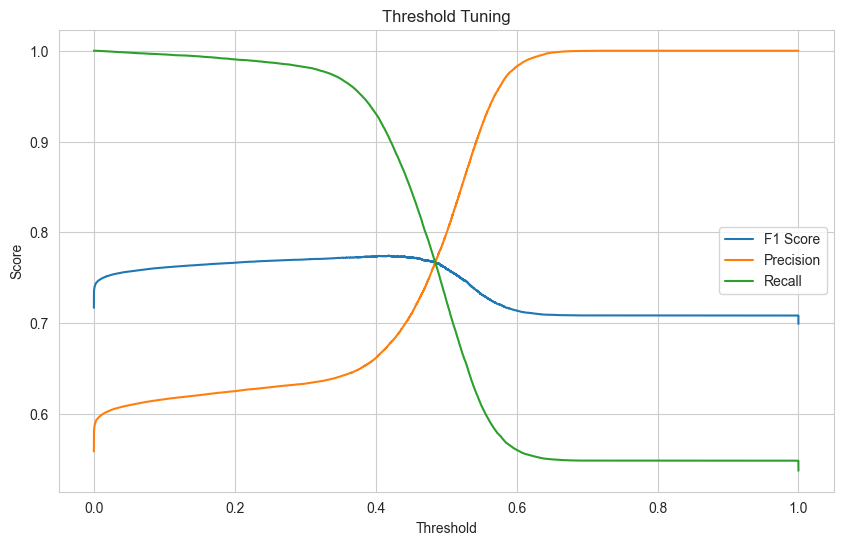

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1 Score')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
sample_df = df_fe.copy()

In [ ]:
def to_prolog_atom(value):
    if pd.isna(value):
        return "unknown"
    s = str(value).strip().lower()
    s = s.replace(" ", "_").replace("-", "_").replace("/", "_")
    return s

def risk_label(score):
    if score < 0.33:
        return "low"
    elif score < 0.66:
        return "medium"
    else:
        return "high"

def fail_label(n):
    return int(n)

facts = []

In [ ]:
for _, row in sample_df.iterrows():
    uid = to_prolog_atom(row['user_id'])

    role = to_prolog_atom(row['role'])
    dept = to_prolog_atom(row['department'])
    comp = to_prolog_atom(row['compliance_status'])
    sens = to_prolog_atom(row['access_sensitivity_level'])
    tod = to_prolog_atom(row['time_of_day'])
    device = to_prolog_atom(row['device_type'])

    rlabel = risk_label(row['risk_score'])
    flogs = fail_label(row['failed_login_attempts'])

    facts.append(f"user({uid}, {role}, {dept}).")
    facts.append(f"role({uid}, {role}).")
    facts.append(f"department({uid}, {dept}).")
    facts.append(f"risk_score({uid}, {rlabel}).")
    facts.append(f"compliance({uid}, {comp}).")
    facts.append(f"failed_logins({uid}, {flogs}).")
    facts.append(f"sensitivity({uid}, {sens}).")
    facts.append(f"time_of_day({uid}, {tod}).")
    facts.append(f"device_type({uid}, {device}).")

with open("facts.pl", "w", encoding="utf-8") as f:
    for line in facts:
        f.write(line + "\n")

print("facts.pl created with", len(sample_df), "users")

facts.pl created with 500000 users
